Measuring overhead up to 100 stages...
Stages: 01 | Avg Time: 0.0631s
Stages: 02 | Avg Time: 0.0567s
Stages: 03 | Avg Time: 0.0690s
Stages: 04 | Avg Time: 0.0871s
Stages: 05 | Avg Time: 0.1036s
Stages: 06 | Avg Time: 0.1164s
Stages: 07 | Avg Time: 0.1382s
Stages: 08 | Avg Time: 0.1564s
Stages: 09 | Avg Time: 0.1634s
Stages: 10 | Avg Time: 0.1879s
Stages: 11 | Avg Time: 0.1939s
Stages: 12 | Avg Time: 0.2045s
Stages: 13 | Avg Time: 0.2314s
Stages: 14 | Avg Time: 0.2536s
Stages: 15 | Avg Time: 0.2714s
Stages: 16 | Avg Time: 0.2865s
Stages: 17 | Avg Time: 0.3101s
Stages: 18 | Avg Time: 0.3196s
Stages: 19 | Avg Time: 0.3418s
Stages: 20 | Avg Time: 0.3592s
Stages: 21 | Avg Time: 0.3654s
Stages: 22 | Avg Time: 0.4012s
Stages: 23 | Avg Time: 0.4004s
Stages: 24 | Avg Time: 0.4100s
Stages: 25 | Avg Time: 0.4454s
Stages: 26 | Avg Time: 0.4640s
Stages: 27 | Avg Time: 0.4813s
Stages: 28 | Avg Time: 0.5440s
Stages: 29 | Avg Time: 0.6293s
Stages: 30 | Avg Time: 0.6043s
Stages: 31 | Avg Time: 0.5679s


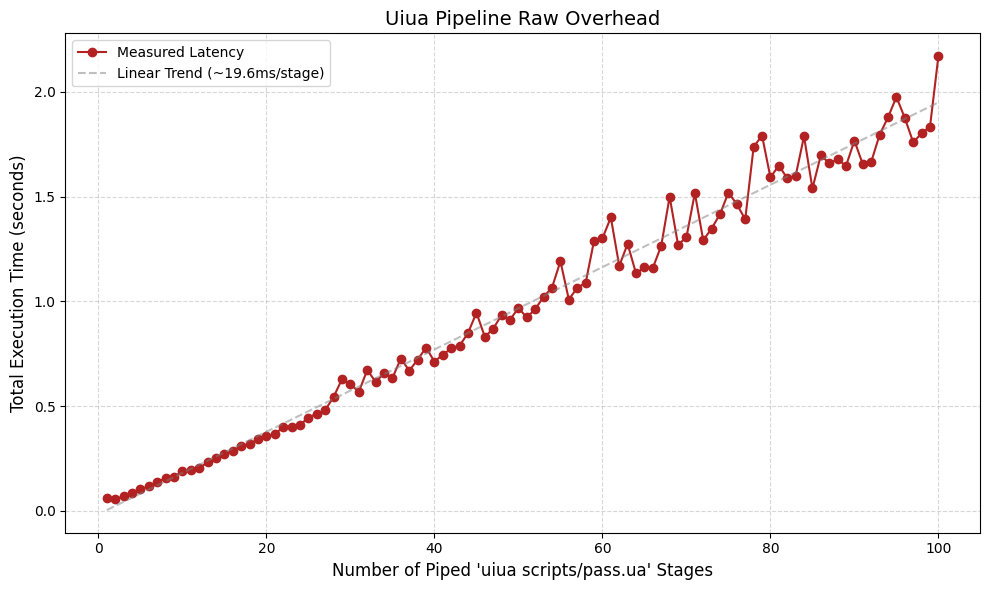

In [ ]:
import subprocess
import time
import matplotlib.pyplot as plt

# Configuration
UIUA_SCRIPT = "scripts/pass.ua"
INPUT_DATA = " ".join(["0 2023 1 1 0 0 60 0 0 -1 -1 -1 -1 -1"] * 410)
MAX_STAGES = 100
REPETITIONS = 3  # Average across runs to smooth out OS jitter

def measure_pipeline(num_stages):
    # Build the command: echo "data" | uiua ... | uiua ...
    uiua_chain = " | ".join([f"uiua {UIUA_SCRIPT}" for _ in range(num_stages)])
    full_cmd = f"echo '{INPUT_DATA}' | {uiua_chain}"
    
    start_time = time.perf_counter()
    # Run through shell to support the piping syntax
    subprocess.run(full_cmd, shell=True, capture_output=True)
    end_time = time.perf_counter()
    
    return end_time - start_time

results = []
stages = list(range(1, MAX_STAGES + 1))

print(f"Measuring overhead up to {MAX_STAGES} stages...")

for s in stages:
    times = [measure_pipeline(s) for _ in range(REPETITIONS)]
    avg_time = sum(times) / REPETITIONS
    results.append(avg_time)
    print(f"Stages: {s:02d} | Avg Time: {avg_time:.4f}s")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(stages, results, marker='o', linestyle='-', color='firebrick', label='Measured Latency')

# Linear Fit (to show the "Tax" per uiua process)
import numpy as np
m, b = np.polyfit(stages, results, 1)
plt.plot(stages, [m*x + b for x in stages], '--', color='gray', alpha=0.5, 
         label=f'Linear Trend (~{m*1000:.1f}ms/stage)')

plt.title("Uiua Pipeline Raw Overhead", fontsize=14)
plt.xlabel("Number of Piped 'uiua scripts/pass.ua' Stages", fontsize=12)
plt.ylabel("Total Execution Time (seconds)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Save and Show
plt.savefig("uiua_overhead_plot.png")
print(f"\nPlot saved to uiua_overhead_plot.png")
print(f"Calculated overhead per uiua process: {m*1000:.2f} ms")
plt.show()

Measuring overhead up to 100 stages...
Stages: 01 | Avg Time: 0.1642s
Stages: 02 | Avg Time: 0.3615s
Stages: 03 | Avg Time: 0.4520s
Stages: 04 | Avg Time: 0.5782s
Stages: 05 | Avg Time: 0.7448s
Stages: 06 | Avg Time: 0.8358s
Stages: 07 | Avg Time: 0.9701s
Stages: 08 | Avg Time: 1.1037s
Stages: 09 | Avg Time: 1.2452s
Stages: 10 | Avg Time: 1.3683s
Stages: 11 | Avg Time: 1.5009s
Stages: 12 | Avg Time: 1.6323s
Stages: 13 | Avg Time: 1.7676s
Stages: 14 | Avg Time: 1.9123s
Stages: 15 | Avg Time: 2.0795s
Stages: 16 | Avg Time: 2.1781s
Stages: 17 | Avg Time: 2.3122s
Stages: 18 | Avg Time: 2.4582s
Stages: 19 | Avg Time: 2.6660s
Stages: 20 | Avg Time: 2.7286s
Stages: 21 | Avg Time: 2.8668s
Stages: 22 | Avg Time: 3.0149s
Stages: 23 | Avg Time: 3.2227s
Stages: 24 | Avg Time: 3.2670s
Stages: 25 | Avg Time: 3.3934s
Stages: 26 | Avg Time: 3.6309s
Stages: 27 | Avg Time: 3.6387s
Stages: 28 | Avg Time: 3.7977s
Stages: 29 | Avg Time: 3.9777s
Stages: 30 | Avg Time: 4.0553s
Stages: 31 | Avg Time: 4.2601s


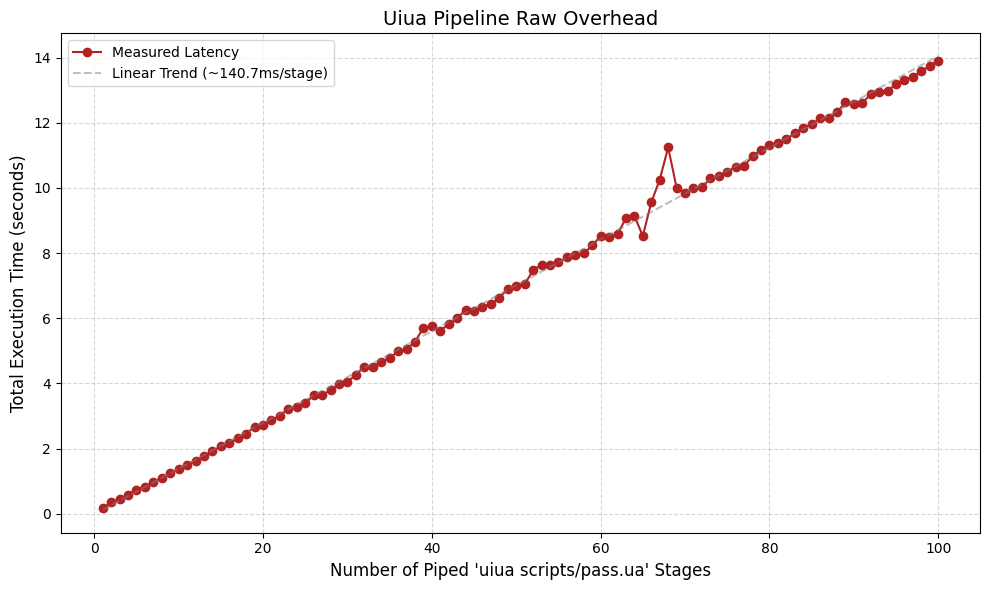

In [3]:
import subprocess
import time
import matplotlib.pyplot as plt

# Configuration
UIUA_SCRIPT = "scripts/pass.ua"
INPUT_DATA = " ".join(["0 2023 1 1 0 0 60 0 0 -1 -1 -1 -1 -1"] * 4100)
MAX_STAGES = 100
REPETITIONS = 3  # Average across runs to smooth out OS jitter

def measure_pipeline(num_stages):
    # Build the command: echo "data" | uiua ... | uiua ...
    uiua_chain = " | ".join([f"uiua {UIUA_SCRIPT}" for _ in range(num_stages)])
    full_cmd = f"echo '{INPUT_DATA}' | {uiua_chain}"
    
    start_time = time.perf_counter()
    # Run through shell to support the piping syntax
    subprocess.run(full_cmd, shell=True, capture_output=True)
    end_time = time.perf_counter()
    
    return end_time - start_time

results = []
stages = list(range(1, MAX_STAGES + 1))

print(f"Measuring overhead up to {MAX_STAGES} stages...")

for s in stages:
    times = [measure_pipeline(s) for _ in range(REPETITIONS)]
    avg_time = sum(times) / REPETITIONS
    results.append(avg_time)
    print(f"Stages: {s:02d} | Avg Time: {avg_time:.4f}s")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(stages, results, marker='o', linestyle='-', color='firebrick', label='Measured Latency')

# Linear Fit (to show the "Tax" per uiua process)
import numpy as np
m, b = np.polyfit(stages, results, 1)
plt.plot(stages, [m*x + b for x in stages], '--', color='gray', alpha=0.5, 
         label=f'Linear Trend (~{m*1000:.1f}ms/stage)')

plt.title("Uiua Pipeline Raw Overhead", fontsize=14)
plt.xlabel("Number of Piped 'uiua scripts/pass.ua' Stages", fontsize=12)
plt.ylabel("Total Execution Time (seconds)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Save and Show
plt.savefig("uiua_overhead_plot.png")
print(f"\nPlot saved to uiua_overhead_plot.png")
print(f"Calculated overhead per uiua process: {m*1000:.2f} ms")
plt.show()